# Monte Carlo Radiomap Three Cubes

This notebook uses `witwin.channel.core.scene` together with `witwin.channel.montecarlo`.
It plots the forward result, the signed shadow-boundary correction field, total and per-component JVP-vs-FD gradients for `tx_x` and `cube1_x` in dB scale, small-grid backward VJP checks, a Sionna RT comparison, summary-level DrJit kernel history plus memory data for forward and backward passes, and a witwin-vs-Sionna speed / GPU-memory bar chart.


In [1]:
from pathlib import Path
import importlib
import math
import sys
import numpy as np

from IPython.display import display

repo_root = Path.cwd().resolve()
if not (repo_root / "witwin").exists():
    repo_root = next(path for path in repo_root.parents if (path / "witwin").exists())
repo_root_str = str(repo_root)
sys.path = [path for path in sys.path if str(Path(path or ".").resolve()) != repo_root_str]
sys.path.insert(0, repo_root_str)

importlib.invalidate_caches()
for module_name in tuple(sys.modules):
    if module_name == "witwin" or module_name.startswith((
        "examples.monte_carlo_radiomap_three_cubes",
        "witwin.",
    )):
        sys.modules.pop(module_name, None)

import examples.monte_carlo_radiomap_three_cubes as mc3

mc3 = importlib.reload(mc3)

DEFAULT_FD_STEP = mc3.DEFAULT_FD_STEP
ThreeCubeExperiment = mc3.ThreeCubeExperiment
plot_forward = mc3.plot_forward
plot_forward_components = mc3.plot_forward_components
plot_shadow_boundary = mc3.plot_shadow_boundary
plot_gradient = mc3.plot_gradient
plot_gradient_components = mc3.plot_gradient_components
plot_sionna_comparison = mc3.plot_sionna_comparison
plot_performance_comparison = mc3.plot_performance_comparison

# Defaults are aligned with:
# tests/main/test_radiomap_sionna_three_cubes_main.py
# tests/main/test_radiomap_gradients_three_cubes_main.py
experiment = ThreeCubeExperiment()
experiment

jitc_llvm_init(): LLVM API initialization failed ..


({'requested': 'auto',
  'resolved': 'rayd_reflection_accumulation',
  'cell_accumulation_mode': 'rayd_optix_atomic_add'},
 {'ad_mode': False,
  'ad_backend': 'disabled',
  'primal_loop_mode': 'symbolic',
  'tx_accumulation_transport_mode': 'disabled',
  'tx_accumulation_transport_step': 0.0,
  'tape_layout_version': 'disabled',
  'samples_per_tx': 1000000,
  'reflection_n_rays': 384,
  'seed': 7,
  'shadow_boundary_mode': 'utd_power_smoothing',
  'shadow_boundary_correction': {'enabled': True,
   'backend': 'drjit',
   'requested_backend': 'auto',
   'candidate_tiles': 13312,
   'candidate_pairs': 851968,
   'candidate_ratio': 1.0,
   'source_total_edges': 13,
   'source_visible_edges': 13,
   'source_visibility_samples_per_edge': 5,
   'tile_shape': [8, 8],
   'band_width_wavelengths': 3.0,
   'weight_aggregation': 'max_weight_weighted_response_average',
   'incident_support': 'direct_los_or_matching_first_blocker_surface_group',
   'domain': 'power',
   'phase_reference': 'none',
  

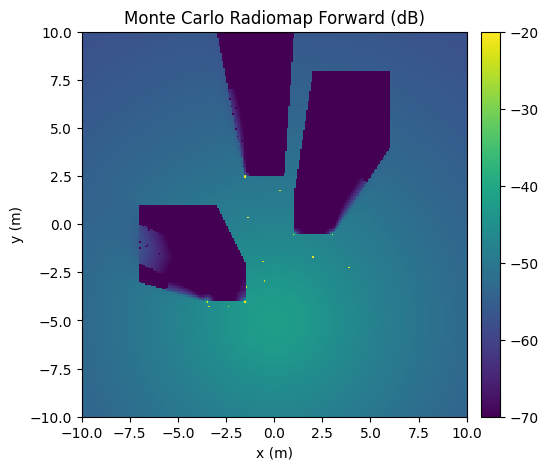

In [2]:
forward = experiment.forward()
plot_forward(forward)
forward.metadata["accumulation_backend"], forward.metadata["monte_carlo"]

{'los': 52670, 'reflection': 9, 'diffraction': 452562, 'total': 505241}

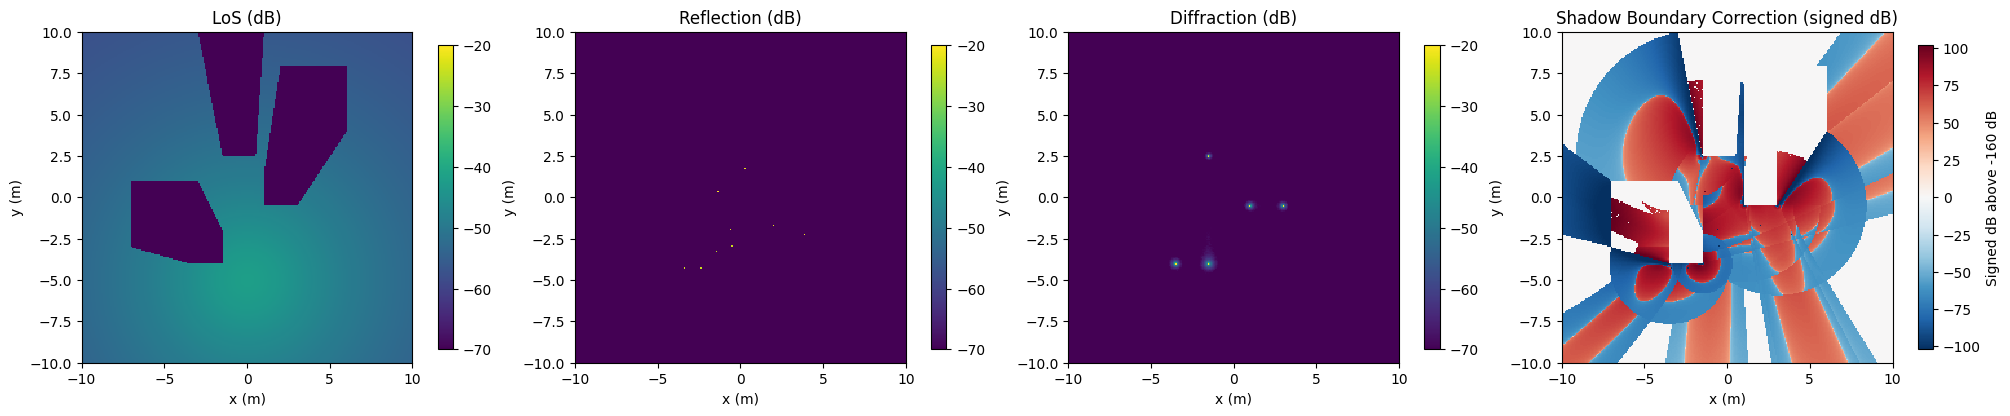

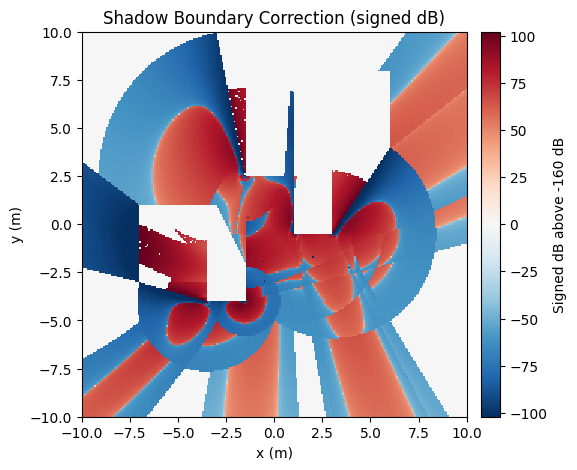

In [3]:
plot_forward_components(forward)
plot_shadow_boundary(forward)
forward.metadata["path_counts"]

{'jvp_abs_sum': 0.2163876488337877,
 'fd_abs_sum': 0.3108021587408093,
 'delta_abs_sum': 0.3105552034865898}

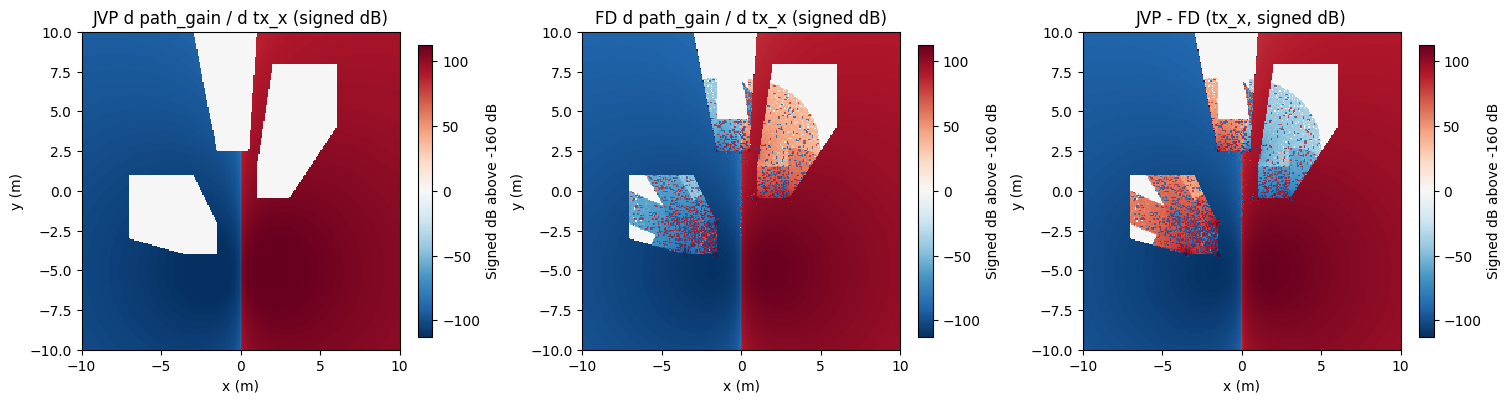

In [4]:
tx_x_gradient = experiment.gradient("tx_x", fd_step=DEFAULT_FD_STEP)
plot_gradient(tx_x_gradient)
{
    "jvp_abs_sum": float(np.abs(tx_x_gradient.jvp).sum()),
    "fd_abs_sum": float(np.abs(tx_x_gradient.fd).sum()),
    "delta_abs_sum": float(np.abs(tx_x_gradient.delta).sum()),
}

{'los': {'jvp_abs_sum': 0.2163876488337877,
  'fd_abs_sum': 0.16823756050143857,
  'delta_abs_sum': 0.16823616176657197},
 'reflection': {'jvp_abs_sum': 0.0,
  'fd_abs_sum': 1.280568540096283e-06,
  'delta_abs_sum': 1.280568540096283e-06},
 'diffraction': {'jvp_abs_sum': 0.0,
  'fd_abs_sum': 0.1432572423368796,
  'delta_abs_sum': 0.1432572423368796}}

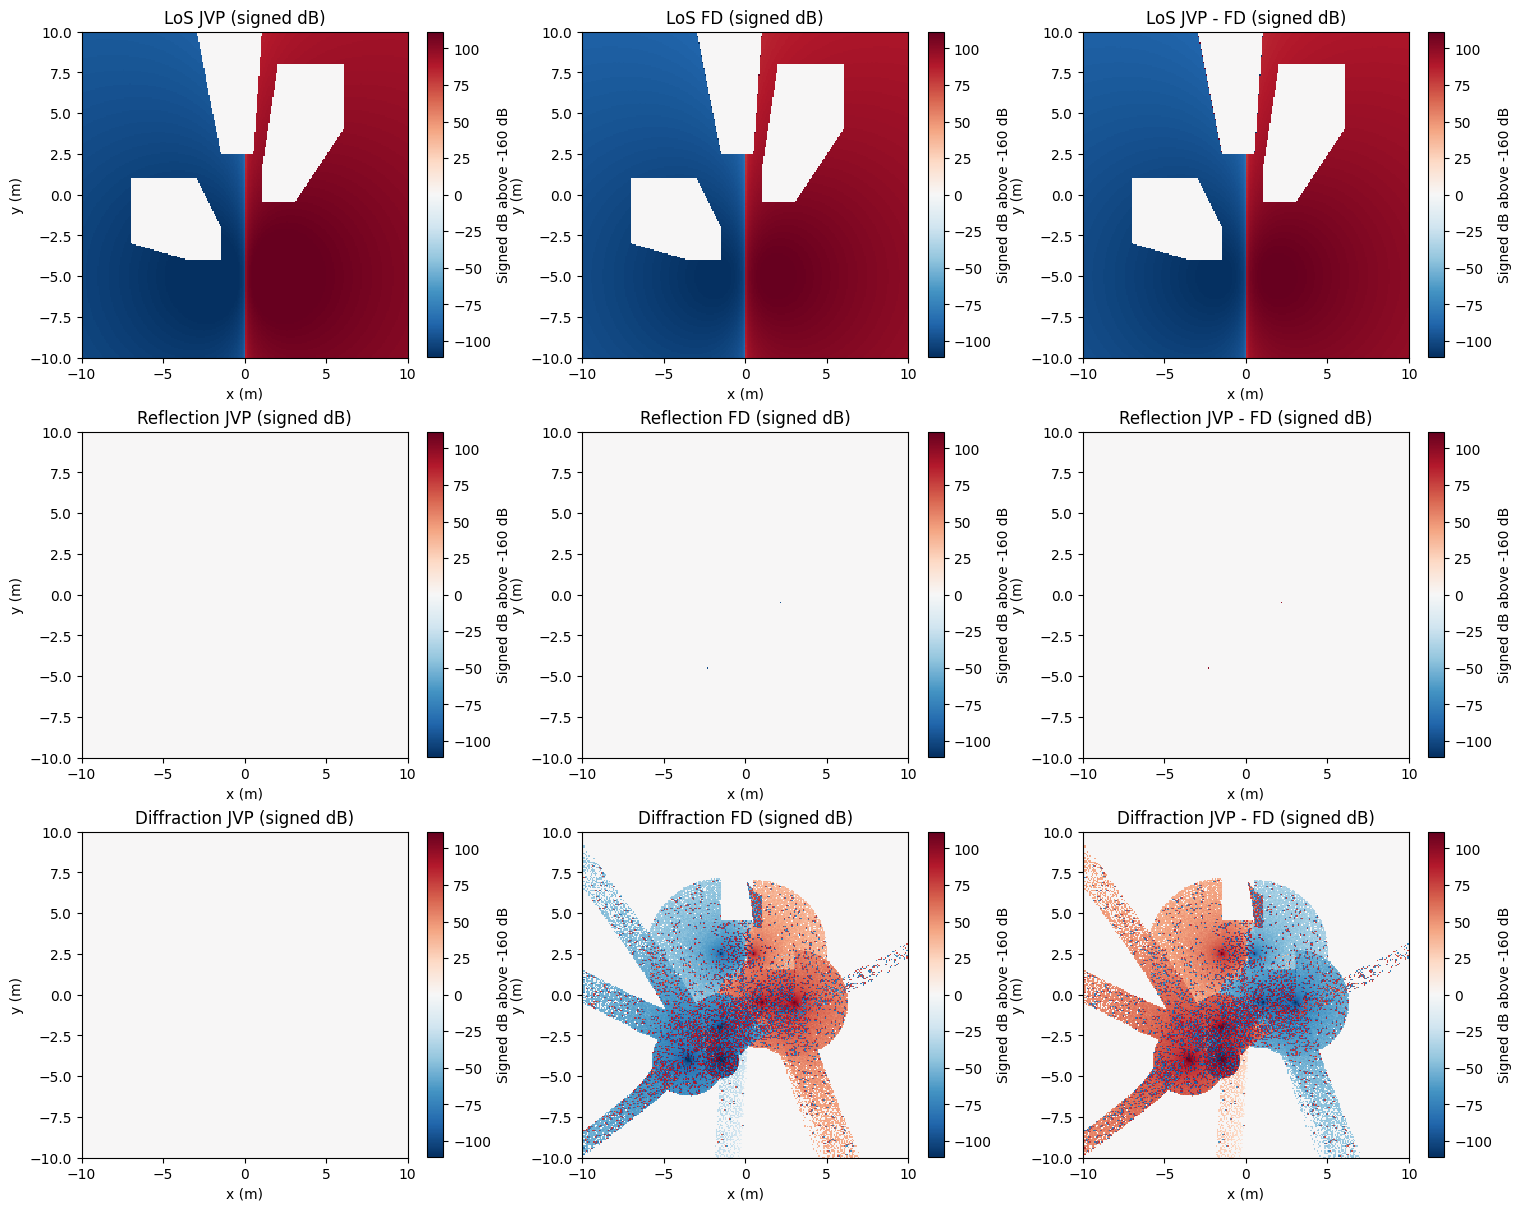

In [5]:
plot_gradient_components(tx_x_gradient)
{
    component: {
        "jvp_abs_sum": float(np.abs(tx_x_gradient.component_jvp[component]).sum()),
        "fd_abs_sum": float(np.abs(tx_x_gradient.component_fd[component]).sum()),
        "delta_abs_sum": float(np.abs(tx_x_gradient.component_delta[component]).sum()),
    }
    for component in ("los", "reflection", "diffraction")
}

{'jvp_abs_sum': 0.0,
 'fd_abs_sum': 0.17388949409934304,
 'delta_abs_sum': 0.17388949409934304}

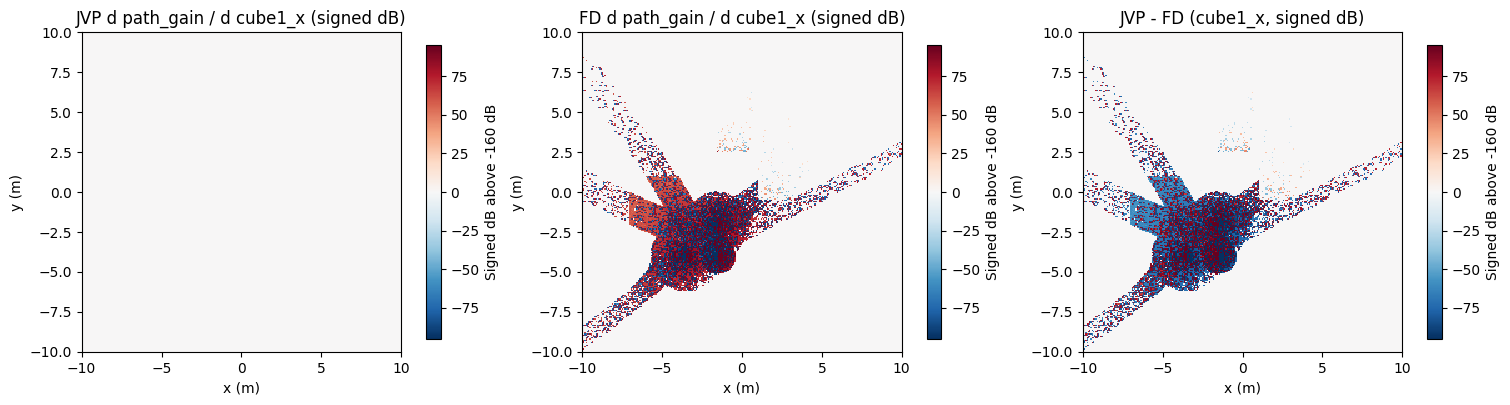

In [6]:
cube1_x_gradient = experiment.gradient("cube1_x", fd_step=DEFAULT_FD_STEP)
plot_gradient(cube1_x_gradient)
{
    "jvp_abs_sum": float(np.abs(cube1_x_gradient.jvp).sum()),
    "fd_abs_sum": float(np.abs(cube1_x_gradient.fd).sum()),
    "delta_abs_sum": float(np.abs(cube1_x_gradient.delta).sum()),
}

{'los': {'jvp_abs_sum': 0.0, 'fd_abs_sum': 0.0, 'delta_abs_sum': 0.0},
 'reflection': {'jvp_abs_sum': 0.0, 'fd_abs_sum': 0.0, 'delta_abs_sum': 0.0},
 'diffraction': {'jvp_abs_sum': 0.0,
  'fd_abs_sum': 0.17388968780618447,
  'delta_abs_sum': 0.17388968780618447}}

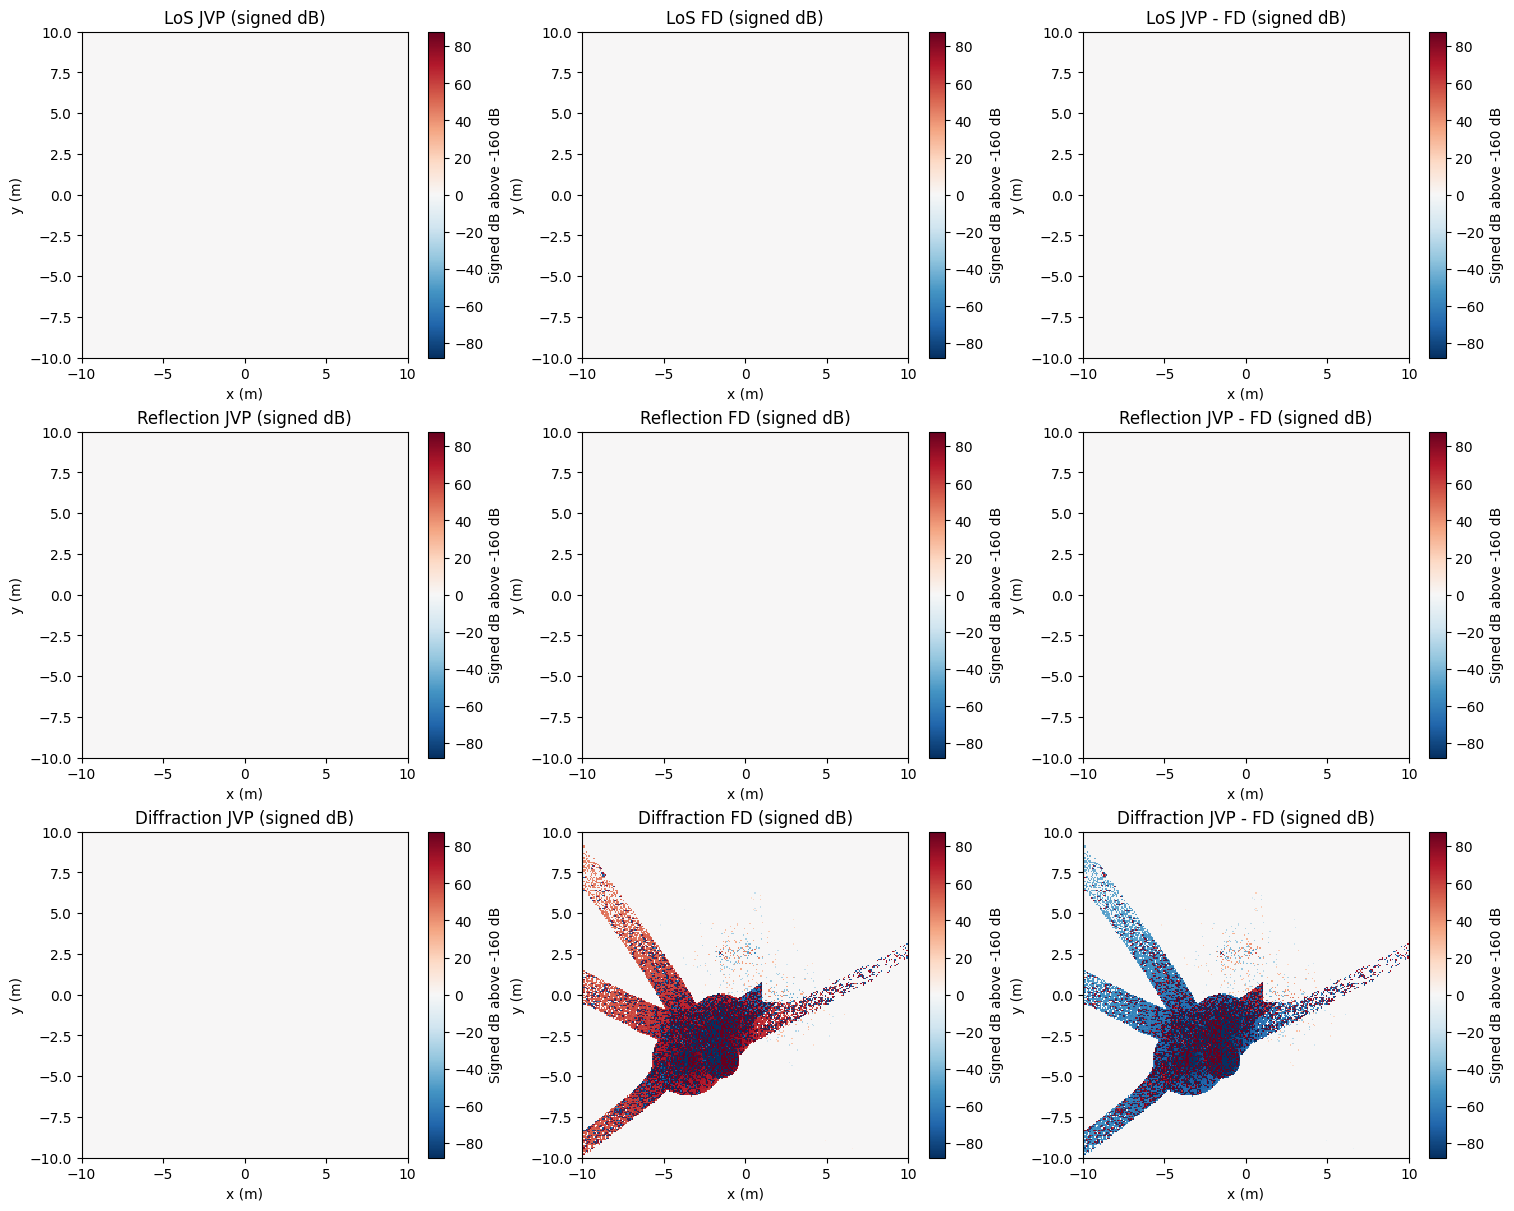

In [7]:
plot_gradient_components(cube1_x_gradient)
{
    component: {
        "jvp_abs_sum": float(np.abs(cube1_x_gradient.component_jvp[component]).sum()),
        "fd_abs_sum": float(np.abs(cube1_x_gradient.component_fd[component]).sum()),
        "delta_abs_sum": float(np.abs(cube1_x_gradient.component_delta[component]).sum()),
    }
    for component in ("los", "reflection", "diffraction")
}

In [8]:
# Backward/VJP smoke check
backward_experiment = ThreeCubeExperiment(
    grid_shape=(32, 32),
    forward_num_samples=32,
    gradient_num_samples=32,
    samples_per_tx=1024,
    seed=7,
)
backward_checks = {
    parameter: backward_experiment.backward(parameter, fd_step=DEFAULT_FD_STEP)
    for parameter in ("tx_x", "cube1_x")
}
summary = {
    parameter: {
        "vjp": float(snapshot.vjp),
        "jvp_sum": float(snapshot.jvp_sum),
        "fd_sum": float(snapshot.fd_sum),
        "vjp_minus_jvp_sum": float(snapshot.vjp_delta),
        "vjp_minus_fd_sum": float(snapshot.fd_delta),
    }
    for parameter, snapshot in backward_checks.items()
}
display(summary)
for snapshot in backward_checks.values():
    assert math.isfinite(snapshot.vjp)
    assert abs(snapshot.vjp_delta) <= max(1.0e-7, 1.0e-4 * max(1.0, abs(snapshot.jvp_sum)))


{'tx_x': {'vjp': 0.00032614695373922586,
  'jvp_sum': 0.000326146985614173,
  'fd_sum': -1.3469152877405577,
  'vjp_minus_jvp_sum': -3.1874947126198094e-11,
  'vjp_minus_fd_sum': 1.347241434694297},
 'cube1_x': {'vjp': 0.0,
  'jvp_sum': 0.0,
  'fd_sum': 1.5460001395695144,
  'vjp_minus_jvp_sum': 0.0,
  'vjp_minus_fd_sum': -1.5460001395695144}}

((256, 256), (256, 256))

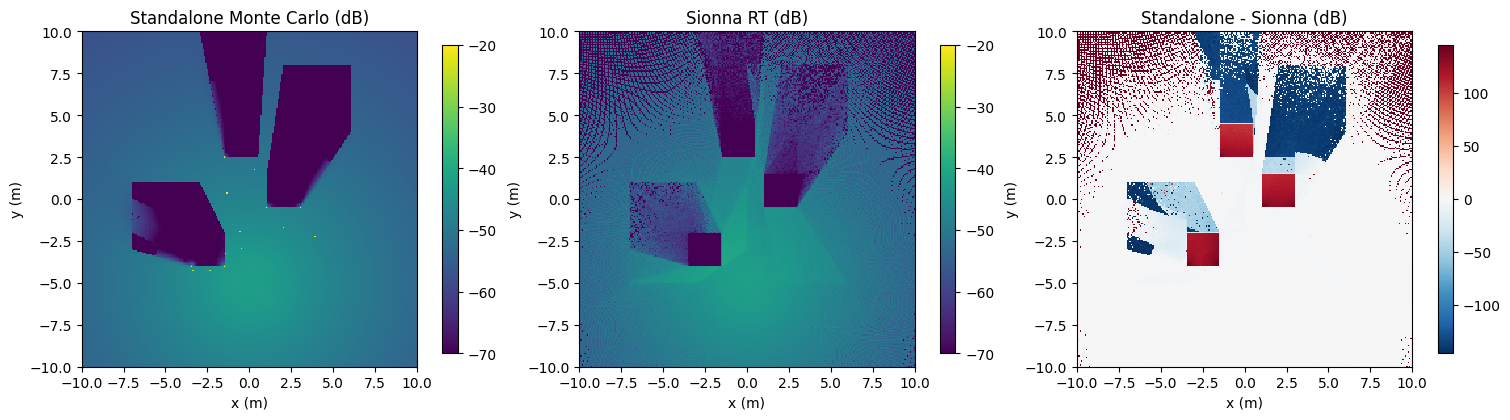

In [9]:
sionna_comparison = experiment.compare_sionna()
plot_sionna_comparison(sionna_comparison)
sionna_comparison.standalone.shape, sionna_comparison.sionna.shape

{'witwin': {'median_ms': 172.04930001753382,
  'peak_memory_mib': 12.84000015258789,
  'samples_ms': (179.70599999534898, 172.04930001753382, 168.10270000132732)},
 'sionna': {'median_ms': 108.27979998430237,
  'peak_memory_mib': 9.508999824523926,
  'samples_ms': (123.50210000295192, 107.08449999219738, 108.27979998430237)}}

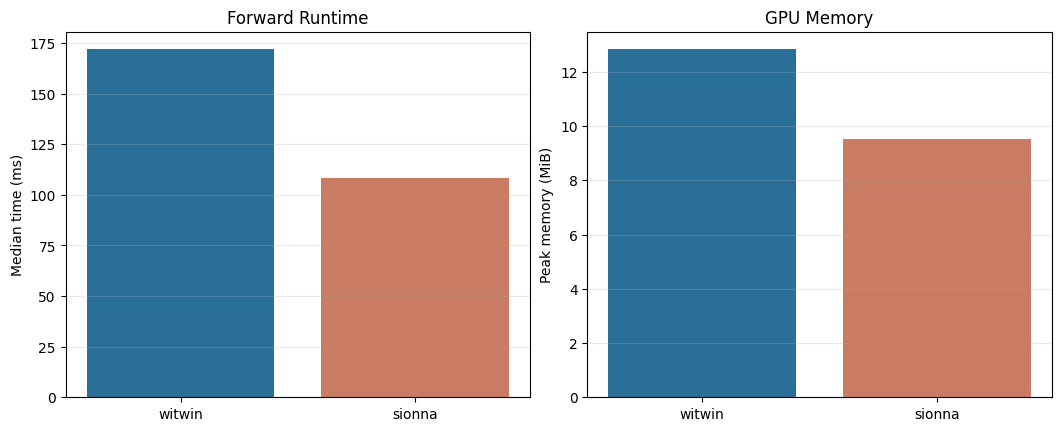

In [10]:
performance = experiment.benchmark_forward_vs_sionna(warmup=0, repeats=3)
plot_performance_comparison(performance)
{
    "witwin": {
        "median_ms": float(performance.witwin.median_ms),
        "peak_memory_mib": None if performance.witwin.peak_memory_mib is None else float(performance.witwin.peak_memory_mib),
        "samples_ms": tuple(float(value) for value in performance.witwin.samples_ms),
    },
    "sionna": {
        "median_ms": float(performance.sionna.median_ms),
        "peak_memory_mib": None if performance.sionna.peak_memory_mib is None else float(performance.sionna.peak_memory_mib),
        "samples_ms": tuple(float(value) for value in performance.sionna.samples_ms),
    },
}

In [11]:
forward_history = experiment.forward_kernel_history()
backward_tx_history = experiment.backward_kernel_history(parameter="tx_x")
backward_cube_history = experiment.backward_kernel_history(parameter="cube1_x")

print("forward kernel count:", forward_history.count)
print(forward_history.pretty())
print("forward memory:", {
    "before": forward_history.memory_before,
    "after": forward_history.memory_after,
    "process_gpu_peak_mib": forward_history.process_gpu_peak_mib,
})
print("\nbackward tx_x kernel count:", backward_tx_history.count)
print(backward_tx_history.pretty())
print("backward tx_x memory:", {
    "before": backward_tx_history.memory_before,
    "after": backward_tx_history.memory_after,
    "process_gpu_peak_mib": backward_tx_history.process_gpu_peak_mib,
})
print("\nbackward cube1_x kernel count:", backward_cube_history.count)
print(backward_cube_history.pretty())
print("backward cube1_x memory:", {
    "before": backward_cube_history.memory_before,
    "after": backward_cube_history.memory_after,
    "process_gpu_peak_mib": backward_cube_history.process_gpu_peak_mib,
})

forward kernel count: 78
{'total_count': 78,
 'by_type': {'KernelType.Reduce': {'count': 7,
                                   'size_sum': 65735,
                                   'size_max': 65536,
                                   'execution_time_ms_sum': 0.08121599932201207,
                                   'small_count_le_128': 6,
                                   'small_count_le_1024': 6,
                                   'large_count_gt_1m': 0},
             'KernelType.JIT': {'count': 63,
                                'size_sum': 984643,
                                'size_max': 65536,
                                'execution_time_ms_sum': 3.059135999530554,
                                'small_count_le_128': 45,
                                'small_count_le_1024': 48,
                                'large_count_gt_1m': 0},
             'KernelType.Other': {'count': 8,
                                  'size_sum': 20,
                                  'size_max'

The new package's steady-state forward kernel-history parity with the legacy package is enforced by pytest,
not by this notebook. See the integration test added alongside this notebook.